In [68]:
import pandas as pd
import numpy as np

In [69]:
#rykin et al 2021 data

raw = pd.read_csv('./raw_data/ryskin_noisyP6_ALL_CRIT_DATA.csv')

# Filter: remove artifacts, restrict to N400 window and centro-parietal electrode cluster
N400_ELECTRODES = ['C3', 'Cz', 'C4', 'CP1', 'CP2', 'P3', 'Pz', 'P4']

mask = (
    (raw['artefact'] == 0) &
    (raw['time_window'] == 'n4') &
    (raw['electrode'].isin(N400_ELECTRODES))
)
n400_clean = raw[mask].copy()

assert n400_clean['artefact'].unique().tolist() == [0], "Artefact filter failed"
assert n400_clean['time_window'].unique().tolist() == ['n4'], "Time window filter failed"
assert n400_clean['electrode'].nunique() == len(N400_ELECTRODES), "Electrode filter failed"

# Derive new columns
n400_clean['dataset'] = 'ryskin_2021'
n400_clean['subject'] = 'ryskin_' + n400_clean['subject']
n400_clean['critical_word'] = n400_clean['stim_char'].str.split().str[-1].str.rstrip('.,!?;:')

# Average over the 8 centro-parietal electrodes within each subject × trial cell
output = (
    n400_clean
    .groupby(['dataset', 'subject', 'stim_char', 'condition', 'critical_word'], as_index=False)
    ['meanAmp'].mean()
    .rename(columns={'stim_char': 'stim'})
    .reset_index(drop=True)
)

# Z-score amplitudes within this dataset
output['meanAmp_z'] = (output['meanAmp'] - output['meanAmp'].mean()) / output['meanAmp'].std()

# Save
import os
os.makedirs('clean_data', exist_ok=True)
output.to_csv('clean_data/ryskin_n400.csv', index=False)
print(f"Saved clean_data/ryskin_n400.csv — {output.shape[0]:,} rows × {output.shape[1]} columns")
display(output.head())

Saved clean_data/ryskin_n400.csv — 3,241 rows × 7 columns


,dataset,subject,stim,condition,critical_word,meanAmp,meanAmp_z
0,ryskin_2021,ryskin_s1,"""He loves me?"" she wondered, plucking off a da...",Synt,petals,2.259037,0.073806
1,ryskin_2021,ryskin_s1,"""It's alive!"" he cackled as he animated this m...",Sem,bounty,6.090838,0.530813
2,ryskin_2021,ryskin_s1,"""Never stay out past midnight,"" was his mother...",SemCrit,admission,1.328902,-0.037128
3,ryskin_2021,ryskin_s1,"""Oh, yes, very impressive,"" she drawled with a...",Control,inflection,1.572209,-0.008110
4,ryskin_2021,ryskin_s1,A lolcat is cat photograph with a humorous ung...,SemCrit,captain,-1.603885,-0.386913


In [70]:
# Michaelov et al. 2024 data
# Already filtered to centroparietal cluster and artifact-free

raw_m = pd.read_csv('./raw_data/michaelov_N400_data.csv')

michaelov = raw_m.copy()
michaelov['dataset'] = 'michaelov_2024'
michaelov['subject'] = 'michaelov_' + michaelov['Subject']

# Average over electrodes within each subject × trial cell
output_m = (
    michaelov
    .rename(columns={
        'Sentence':   'stim',
        'Condition':  'condition',
        'TargetWord': 'critical_word',
        'N400':       'meanAmp',
    })
    .groupby(['dataset', 'subject', 'stim', 'condition', 'critical_word'], as_index=False)
    ['meanAmp'].mean()
    .reset_index(drop=True)
)

# Z-score amplitudes within this dataset
output_m['meanAmp_z'] = (output_m['meanAmp'] - output_m['meanAmp'].mean()) / output_m['meanAmp'].std()

output_m.to_csv('clean_data/michaelov_n400.csv', index=False)
print(f"Saved clean_data/michaelov_n400.csv — {output_m.shape[0]:,} rows × {output_m.shape[1]} columns")
display(output_m.head())

Saved clean_data/michaelov_n400.csv — 5,526 rows × 7 columns


,dataset,subject,stim,condition,critical_word,meanAmp,meanAmp_z
0,michaelov_2024,michaelov_CP01,"After a week, they gave up on the missing hike...",Implaus,boss,-0.700000,-0.207009
1,michaelov_2024,michaelov_CP01,"After swimming the English Channel, Bonita was...",Unrel,blue,6.765556,0.876408
2,michaelov_2024,michaelov_CP01,"After the divorce, she had to move out of the ...",Unrel,ugly,13.557778,1.862108
3,michaelov_2024,michaelov_CP01,"After the flood, the house smelled of mildew a...",BC,ruined,6.238889,0.799977
4,michaelov_2024,michaelov_CP01,"After the most recent price increase, the smal...",Implaus,gown,2.457778,0.251254


In [71]:
# Frank et al. 2015 data (via Lopopolo & Rabovsky 2024)
# Per-subject N400 amplitudes for 205 naturalistic sentences.
# Already averaged over the centroparietal cluster (no per-electrode rows).
# N400base is the pre-stimulus baseline amplitude; N400 is the baseline-corrected DV.
#
# Sentence text recovery:
# Lopopolo uses anonymous IDs (sent_0…sent_204) — full text is not published.
# Both Lopopolo and De Varda et al. 2024 use the same 205 Frank (2013/2015) sentences,
# so we reconstruct the mapping by matching each Lopopolo word sequence against De Varda.
# Two normalizations are required before matching:
#   1. Lowercase (Lopopolo keeps proper-noun capitalisation; De Varda does not consistently)
#   2. Strip surrounding punctuation (De Varda attaches punctuation to words, e.g. "toilet.")
# We use the subject with the most artifact-free words per sentence as the fingerprint source,
# then verify every word in that fingerprint appears as a contiguous substring in the
# corresponding De Varda sentence. All 205 matches are asserted to be unique (bijective).

import re

def _normalize(word):
    """Lowercase and strip surrounding non-alphanumeric characters."""
    return re.sub(r'^[^a-zA-Z0-9]+|[^a-zA-Z0-9]+$', '', word.lower())

raw_f = pd.read_csv('./raw_data/frank_2015_from_lopopolo_2024.csv')
dev   = pd.read_csv('./raw_data/frank_2015_from_devarda_2024.csv')

# Build De Varda normalized fingerprints (words in presentation order)
dev_fingerprints = (
    dev.groupby('sent_id')
       .apply(
           lambda g: ' '.join(_normalize(w) for w in g.sort_values('context_length')['word']),
           include_groups=False,
       )
)
dev_sent_text = dev.groupby('sent_id')['sentence'].first()

# For each Lopopolo sentence, use the subject with the most words
# (artifact rejection can leave some subjects with very sparse sequences)
words_per_subj     = raw_f.groupby(['sentence', 'subject'])['word'].count()
best_subj_per_sent = words_per_subj.groupby('sentence').idxmax().apply(lambda x: x[1])

lop_fingerprints = {}
for sent_id in raw_f['sentence'].unique():
    best_subj = best_subj_per_sent[sent_id]
    words = raw_f[(raw_f['sentence'] == sent_id) & (raw_f['subject'] == best_subj)]['word'].tolist()
    lop_fingerprints[sent_id] = ' '.join(_normalize(w) for w in words)

# Match each Lopopolo sentence ID to a De Varda sentence via substring search
sent_text_map = {}
for lop_id, lop_fp in lop_fingerprints.items():
    matches = [
        dev_sent_text[dev_id]
        for dev_id, dev_fp in dev_fingerprints.items()
        if lop_fp in dev_fp
    ]
    assert len(matches) == 1, (
        f"Expected exactly 1 De Varda match for {lop_id} (fp='{lop_fp}'), got {len(matches)}"
    )
    sent_text_map[lop_id] = matches[0]

assert len(sent_text_map) == 205, \
    f"Expected 205 sentence mappings, got {len(sent_text_map)}"
assert len(set(sent_text_map.values())) == 205, \
    "Sentence-text mapping is not bijective — a De Varda sentence was matched more than once"

print(f"Mapped all 205 Lopopolo sentence IDs to full sentence text (bijective ✓)")

# Build output
frank = raw_f.copy()
frank['dataset']   = 'frank_2015'
frank['subject']   = 'frank_' + frank['subject']
frank['stim']      = frank['sentence'].map(sent_text_map)
frank['condition'] = 'naturalistic'  # no violation manipulation

output_f = frank[['dataset', 'subject', 'stim', 'condition', 'word', 'N400']].rename(columns={
    'word': 'critical_word',
    'N400': 'meanAmp',
}).reset_index(drop=True)

# Z-score amplitudes within this dataset
output_f['meanAmp_z'] = (output_f['meanAmp'] - output_f['meanAmp'].mean()) / output_f['meanAmp'].std()

os.makedirs('clean_data', exist_ok=True)
output_f.to_csv('clean_data/frank_n400.csv', index=False)
print(f"Saved clean_data/frank_n400.csv — {output_f.shape[0]:,} rows × {output_f.shape[1]} columns")
display(output_f.head())

Mapped all 205 Lopopolo sentence IDs to full sentence text (bijective ✓)
Saved clean_data/frank_n400.csv — 37,112 rows × 7 columns


,dataset,subject,stim,condition,critical_word,meanAmp,meanAmp_z
0,frank_2015,frank_subj_1,I cannot tell you more.,naturalistic,cannot,-1.859916,-0.452366
1,frank_2015,frank_subj_1,I cannot tell you more.,naturalistic,tell,-0.326976,-0.054660
2,frank_2015,frank_subj_1,I cannot tell you more.,naturalistic,you,3.984934,1.064024
3,frank_2015,frank_subj_1,I cannot tell you more.,naturalistic,more,6.883699,1.816081
4,frank_2015,frank_subj_2,I cannot tell you more.,naturalistic,cannot,0.159258,0.071489


mean     se  n_subjects
dataset        condition                          
ryskin_2021    Control    0.192  0.041          24
               Sem       -0.317  0.043          24
               SemCrit    0.019  0.053          24
               Synt       0.118  0.058          24
michaelov_2024 BC         0.098  0.044          50
               Implaus   -0.193  0.031          50
               Rel        0.097  0.039          50
               Unrel     -0.002  0.041          50

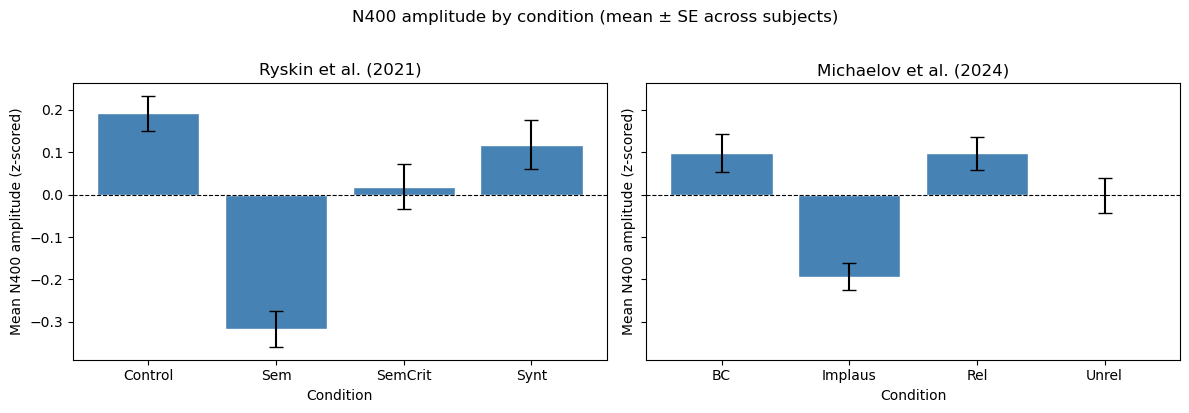

In [72]:
import matplotlib.pyplot as plt

ryskin    = pd.read_csv('clean_data/ryskin_n400.csv')
michaelov = pd.read_csv('clean_data/michaelov_n400.csv')

# Aggregate to subject-level means per condition, then compute grand mean ± SE across subjects
def condition_summary(df):
    subj_means = df.groupby(['condition', 'subject'])['meanAmp_z'].mean()
    return subj_means.groupby('condition').agg(
        mean='mean',
        se=lambda x: x.std() / len(x) ** 0.5,
        n_subjects='count',
    ).reset_index()

ryskin_summary    = condition_summary(ryskin)
michaelov_summary = condition_summary(michaelov)

# Summary table
combined = pd.concat(
    [ryskin_summary.assign(dataset='ryskin_2021'),
     michaelov_summary.assign(dataset='michaelov_2024')],
).set_index(['dataset', 'condition'])[['mean', 'se', 'n_subjects']].round(3)
display(combined)

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, (summary, title) in zip(axes, [
    (ryskin_summary,    'Ryskin et al. (2021)'),
    (michaelov_summary, 'Michaelov et al. (2024)'),
]):
    ax.bar(summary['condition'], summary['mean'], yerr=summary['se'],
           capsize=5, color='steelblue', edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Condition')
    ax.set_ylabel('Mean N400 amplitude (z-scored)')

plt.suptitle('N400 amplitude by condition (mean ± SE across subjects)', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
import re

combined = pd.concat([
    pd.read_csv('clean_data/ryskin_n400.csv'),
    pd.read_csv('clean_data/michaelov_n400.csv'),
    pd.read_csv('clean_data/frank_n400.csv'),
], ignore_index=True)

def _clean_stim(s):
    s = s.strip()
    # Remove all quotation marks (straight, curly, single, double, backtick)
    s = re.sub(r'[\u2018\u2019\u201c\u201d"\'`]+', '', s)
    # Strip trailing punctuation
    s = s.rstrip('.,!?;:')
    return s.strip()

combined['stim'] = combined['stim'].apply(_clean_stim)

# stim_id: unique integer per (stim, critical_word) pair
stim_keys = pd.Series(list(zip(combined['stim'], combined['critical_word'])))
combined['stim_id']    = pd.factorize(stim_keys)[0]
combined['stim_lower'] = combined['stim'].str.lower()
combined = combined[['dataset', 'subject', 'stim_id', 'stim', 'stim_lower', 'condition', 'critical_word', 'meanAmp', 'meanAmp_z']]

combined.to_csv('combined_clean_n400.csv', index=False)
print(f"Saved combined_clean_n400.csv — {combined.shape[0]:,} rows × {combined.shape[1]} columns")
print(combined.groupby('dataset')[['meanAmp', 'meanAmp_z']].describe().round(3))

In [74]:
# Stimulus manifest: one row per unique (stimulus, critical_word) pair
manifest = (
    combined[['dataset', 'stim_id', 'stim', 'stim_lower', 'critical_word']]
    .drop_duplicates()
    .sort_values(['dataset', 'stim_id', 'critical_word'])
    .reset_index(drop=True)
)

manifest.to_csv('stims_for_modeling.csv', index=False)
print(f"Saved stims_for_modeling.csv — {manifest.shape[0]:,} rows × {manifest.shape[1]} columns")
print(f"  Unique stimuli:        {manifest['stim_id'].nunique():,}")
print(f"  Unique critical words: {manifest['critical_word'].nunique():,}")
display(manifest.head(10))

Saved stims_for_modeling.csv — 2,808 rows × 5 columns
  Unique stimuli:        2,808
  Unique critical words: 1,320


,dataset,stim_id,stim,stim_lower,critical_word
0,frank_2015,1140,I cannot tell you more,i cannot tell you more,cannot
1,frank_2015,1141,I cannot tell you more,i cannot tell you more,tell
2,frank_2015,1142,I cannot tell you more,i cannot tell you more,you
3,frank_2015,1143,I cannot tell you more,i cannot tell you more,more
4,frank_2015,1144,Helen ran to the toilet,helen ran to the toilet,ran
5,frank_2015,1145,Helen ran to the toilet,helen ran to the toilet,the
6,frank_2015,1146,Helen ran to the toilet,helen ran to the toilet,toilet
7,frank_2015,1147,Helen ran to the toilet,helen ran to the toilet,to
8,frank_2015,1148,He uses his belt on you,he uses his belt on you,uses
9,frank_2015,1149,He uses his belt on you,he uses his belt on you,his
